# Binning Continuous Variables
### A first introduction, using the Titanic dataset

**Python for Data Science - Introduction to Data Preparation**

---

**Binning** means taking a continuous number and sorting it into groups. Age becomes *child / adult / senior*. Fare becomes *cheap / mid / expensive*.

You are deliberately throwing information away. A passenger aged 23 and one aged 34 become indistinguishable. So why do it?

Because some patterns are **invisible until you group**. If survival jumps at a particular age rather than drifting smoothly upward, no amount of staring at 891 individual ages will show you that. Grouping will.

This notebook covers the two tools you will use for almost everything:

| Tool | Use it when |
|---|---|
| **`pd.cut`** | you know where the boundaries should go |
| **`pd.qcut`** | you don't, and you want groups of equal size |

---

## 1. Setup

The Titanic dataset ships with seaborn. One row is one passenger. We only need two of its columns: `age` and `fare`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 150)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

titanic = sns.load_dataset('titanic')

print(f'{titanic.shape[0]} passengers\n')
titanic[['survived', 'age', 'fare', 'sex', 'pclass']].head()

891 passengers



,survived,age,fare,sex,pclass
0,0,22.0,7.2500,male,3
1,1,38.0,71.2833,female,1
2,1,26.0,7.9250,female,3
3,1,35.0,53.1000,female,1
4,0,35.0,8.0500,male,3


In [2]:
titanic[['age', 'fare']].describe().round(2)

,age,fare
count,714.00,891.00
mean,29.70,32.20
std,14.53,49.69
min,0.42,0.00
25%,20.12,7.91
50%,28.00,14.45
75%,38.00,31.00
max,80.00,512.33


---

## 2. The problem: a pattern you cannot see

Did age affect a passenger's chance of surviving the Titanic?

The obvious first move is a correlation.

In [3]:
r = titanic['age'].corr(titanic['survived'])

print(f'correlation between age and survival: {r:.3f}')
print()
print('Essentially zero. Read literally, that says age made no difference.')

correlation between age and survival: -0.077

Essentially zero. Read literally, that says age made no difference.


So age did not matter? That should feel wrong. *"Women and children first"* was the evacuation instruction actually given on that ship.

The problem is that **a correlation only measures a straight-line relationship**. It asks "does survival rise steadily as age rises?" - and the answer really is no. But that is not the question we care about. We want to know whether something changes at a particular age.

Let us try looking at survival for each individual age instead.

In [4]:
by_exact_age = titanic.groupby('age')['survived'].agg(passengers='size', survival_rate='mean')

print(f'distinct ages in the data: {len(by_exact_age)}')
print(f'ages with only one passenger: {(by_exact_age["passengers"] == 1).sum()}')
print()
by_exact_age.head(12)

distinct ages in the data: 88
ages with only one passenger: 16



,passengers,survival_rate
age,,
0.42,1,1.000000
0.67,1,1.000000
0.75,2,1.000000
0.83,2,1.000000
0.92,1,1.000000
1.00,7,0.714286
2.00,10,0.300000
3.00,6,0.833333
4.00,10,0.700000


This is unusable. Most ages have a handful of passengers, so every survival rate is 0%, 100%, or 50% - noise, not signal. Spreading 891 people across that many distinct values leaves nothing to stand on.

We have the opposite problems in the two attempts:

- The **correlation** grouped everyone together and looked for one straight line. Too coarse.
- The **exact ages** split everyone apart. Too fine.

Binning is the middle ground.

---

## 3. Your first bins: `pd.cut`

`pd.cut` slices a column at boundaries **you choose**. You pass the cut points and, optionally, a name for each group.

In [5]:
AGE_BINS   = [0, 16, 30, 50, 100]
AGE_LABELS = ['Child (under 16)', 'Young adult (16-29)', 'Adult (30-49)', 'Senior (50+)']

age_band = pd.cut(titanic['age'],
                  bins=AGE_BINS,
                  labels=AGE_LABELS,
                  right=False)          # left edge included, right edge excluded

print('the first ten passengers:\n')
pd.DataFrame({'age': titanic['age'], 'band': age_band}).head(10)

the first ten passengers:



,age,band
0,22.0,Young adult (16-29)
1,38.0,Adult (30-49)
2,26.0,Young adult (16-29)
3,35.0,Adult (30-49)
4,35.0,Adult (30-49)
5,NaN,NaN
6,54.0,Senior (50+)
7,2.0,Child (under 16)
8,27.0,Young adult (16-29)
9,14.0,Child (under 16)


In [6]:
age_band.value_counts().sort_index().to_frame('passengers')

,passengers
age,
Child (under 16),83
Young adult (16-29),301
Adult (30-49),256
Senior (50+),74


Four groups, each with enough people to say something about. Now ask the original question again.

In [7]:
by_band = titanic.groupby(age_band, observed=False)['survived'].agg(
    passengers='size', survived='sum', survival_rate='mean')

# state the comparison explicitly rather than leaving it to the eye
child_rate = titanic.loc[titanic['age'] < 16, 'survived'].mean()
adult_rate = titanic.loc[titanic['age'] >= 16, 'survived'].mean()
print(f'children under 16 : {child_rate:.1%} survived')
print(f'everyone 16 and up: {adult_rate:.1%} survived')
print(f'difference        : {child_rate - adult_rate:+.1%}')
print()

by_band.style.format({'survival_rate': '{:.1%}'})

children under 16 : 59.0% survived
everyone 16 and up: 38.2% survived
difference        : +20.8%



,passengers,survived,survival_rate
age,,,
Child (under 16),83,49,59.0%
Young adult (16-29),301,107,35.5%
Adult (30-49),256,107,41.8%
Senior (50+),74,27,36.5%


**There it is.** Children survived at a markedly higher rate than every adult group, and the adult groups are broadly similar to each other.

That is why the correlation was near zero. The relationship is not a slope, it is a **step**: one group is different and the rest are much of a muchness. A correlation cannot represent a step, so it reported nothing. Binning made the step visible in a single line of code.

> This is the strongest argument for binning. It is not just tidying - it can surface a real effect that other summaries hide completely.

Let us see the same thing as a picture.

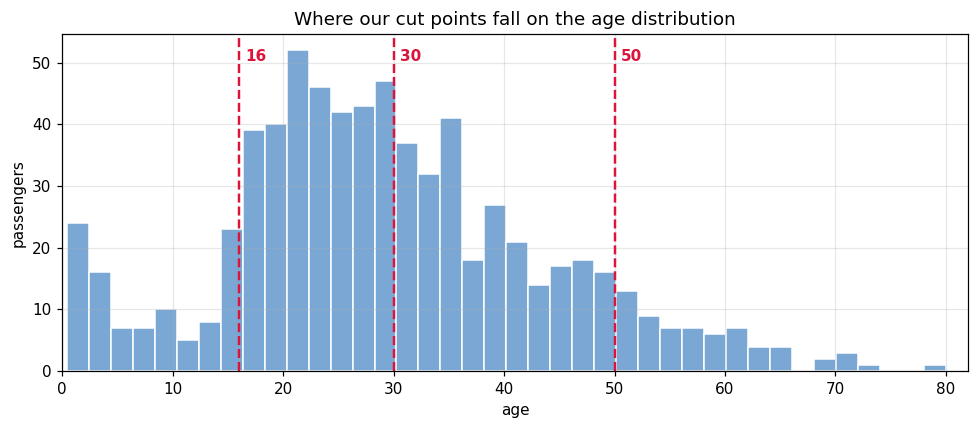

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(titanic['age'].dropna(), bins=40, color='#7BA7D4', edgecolor='white')

for edge in AGE_BINS[1:-1]:
    ax.axvline(edge, color='crimson', linestyle='--', linewidth=1.6)
    ax.text(edge + 0.6, ax.get_ylim()[1] * 0.92, str(edge),
            color='crimson', fontsize=10, fontweight='bold')

ax.set_xlabel('age')
ax.set_ylabel('passengers')
ax.set_title('Where our cut points fall on the age distribution')
ax.set_xlim(0, titanic['age'].max() + 2)
plt.tight_layout()
plt.show()

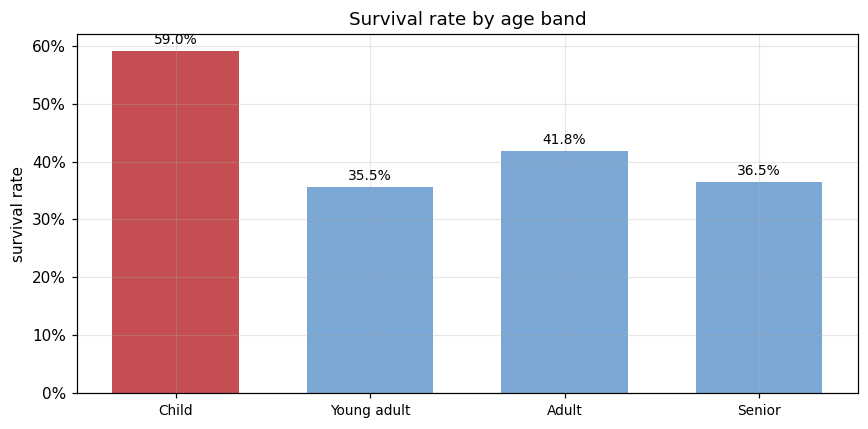

In [9]:
rates = by_band['survival_rate']

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C44E52' if v == rates.max() else '#7BA7D4' for v in rates]
ax.bar(range(len(rates)), rates.values, color=colors, width=0.65)

ax.set_xticks(range(len(rates)))
ax.set_xticklabels([l.split(' (')[0] for l in rates.index], fontsize=9)
ax.set_ylabel('survival rate')
ax.set_title('Survival rate by age band')
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')

for i, v in enumerate(rates.values):
    ax.text(i, v + 0.012, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---

## 4. How `pd.cut` actually behaves

Three details that trip people up. All three are worth ten minutes now rather than an hour later.

### 4a. What you get back

`pd.cut` does not return strings. It returns a **categorical** column that knows its groups are in order.

In [10]:
print('dtype     :', age_band.dtype)
print('ordered?  :', age_band.cat.ordered)
print('groups    :', list(age_band.cat.categories))
print()
print('Because the order is stored, comparisons work:')
print('  passengers under 30:', (age_band < 'Adult (30-49)').sum())
print()
print('And value_counts().sort_index() comes out in the right order,')
print('rather than alphabetically.')

dtype     : category
ordered?  : True
groups    : ['Child (under 16)', 'Young adult (16-29)', 'Adult (30-49)', 'Senior (50+)']

Because the order is stored, comparisons work:
  passengers under 30: 384

And value_counts().sort_index() comes out in the right order,
rather than alphabetically.


### 4b. `right=` decides which end of the bin is closed

Every bin has two edges. `right=` says which edge belongs to which bin - and for ages this genuinely matters. Should a passenger who is exactly 16 be a child or a young adult?

In [11]:
demo_ages = pd.Series([0.5, 15, 16, 29, 30, 49, 50, 80])

comparison = pd.DataFrame({
    'age': demo_ages,
    'right=False': pd.cut(demo_ages, AGE_BINS, labels=AGE_LABELS, right=False),
    'right=True' : pd.cut(demo_ages, AGE_BINS, labels=AGE_LABELS, right=True),
})
comparison

,age,right=False,right=True
0,0.5,Child (under 16),Child (under 16)
1,15.0,Child (under 16),Child (under 16)
2,16.0,Young adult (16-29),Child (under 16)
3,29.0,Young adult (16-29),Young adult (16-29)
4,30.0,Adult (30-49),Young adult (16-29)
5,49.0,Adult (30-49),Adult (30-49)
6,50.0,Senior (50+),Adult (30-49)
7,80.0,Senior (50+),Senior (50+)


With `right=False` the bins are `[0, 16)` `[16, 30)` ... - the left edge is included, so a 16-year-old is a young adult. That is what we want, and it is why we passed it.

With the default `right=True` the bins are `(0, 16]` `(16, 30]` ... - a 16-year-old is still a child, and notice that an age of exactly **0 becomes `NaN`**, because `0` is not *greater than* the lower edge of `0`.

> **Rule of thumb:** for ages, use `right=False`. It matches how people actually talk - "under 16" means 16 is not included.

### 4c. Anything outside your bins silently becomes `NaN`

`pd.cut` will not warn you if a value falls outside the range you supplied. It just returns nothing for that row.

In [12]:
# A deliberately careless set of edges - the oldest passengers fall off the end.
careless = pd.cut(titanic['age'], bins=[0, 16, 30, 50], labels=['A', 'B', 'C'], right=False)

lost = careless.isna().sum() - titanic['age'].isna().sum()

print(f'oldest passenger        : {titanic["age"].max()}')
print(f'highest bin edge we gave: 50')
print(f'passengers thrown away  : {lost}')
print()
print('No error. No warning. They are simply gone.')

oldest passenger        : 80.0
highest bin edge we gave: 50
passengers thrown away  : 74

No error. No warning. They are simply gone.


This is why our real bins end at **100** rather than at the oldest age in the data. Leave headroom, and always check that your bins caught everyone.

---

## 5. The missing values problem

This is the most important section in the notebook, because on this dataset it affects a fifth of the passengers.

Count how many people ended up in a band, and compare it to how many people are on the ship.

In [13]:
print(f'passengers in the dataset  : {len(titanic)}')
print(f'passengers in an age band  : {age_band.notna().sum()}')
print(f'unaccounted for            : {age_band.isna().sum()}')
print()
print(f'their age is missing       : {titanic["age"].isna().sum()}')
print(f'that is {titanic["age"].isna().mean():.0%} of everyone on board')

passengers in the dataset  : 891
passengers in an age band  : 714
unaccounted for            : 177

their age is missing       : 177
that is 20% of everyone on board


`pd.cut` cannot bin a value it does not have, so every passenger with no recorded age comes back as `NaN`.

And here is the dangerous part - those passengers then **disappear from every summary you write**, without comment:

In [14]:
print('our survival table from section 3 covered:')
print(f'  {by_band["passengers"].sum()} passengers')
print(f'  out of {len(titanic)} on board')
print()
print(f'  {len(titanic) - by_band["passengers"].sum()} people were never in it.')

our survival table from section 3 covered:
  714 passengers
  out of 891 on board

  177 people were never in it.


The table looked complete. It was not. Nothing in the output hinted that a fifth of the ship had been left out.

### The fix: give them a band of their own

Rather than pretending they do not exist, make "we don't know" an explicit group. Then it shows up in every table and you can see exactly how big it is.

In [15]:
age_band_full = age_band.cat.add_categories('Age unknown').fillna('Age unknown')

print(f'passengers now accounted for: {age_band_full.notna().sum()} of {len(titanic)}')
print()
age_band_full.value_counts().sort_index().to_frame('passengers')

passengers now accounted for: 891 of 891



,passengers
age,
Child (under 16),83
Young adult (16-29),301
Adult (30-49),256
Senior (50+),74
Age unknown,177


In [16]:
full_table = titanic.groupby(age_band_full, observed=False)['survived'].agg(
    passengers='size', survival_rate='mean')

full_table.style.format({'survival_rate': '{:.1%}'})

,passengers,survival_rate
age,,
Child (under 16),83,59.0%
Young adult (16-29),301,35.5%
Adult (30-49),256,41.8%
Senior (50+),74,36.5%
Age unknown,177,29.4%


### Is "unknown" just noise, or is it telling us something?

Compare the survival rate of the unknown-age group against the others in the table above. If it were missing at random you would expect it to sit near the overall average.

Let us look at who those passengers actually were.

In [17]:
unknown = titanic['age'].isna()

profile = pd.DataFrame({
    'age recorded'    : [(~unknown).sum(),
                         titanic.loc[~unknown, 'survived'].mean(),
                         (titanic.loc[~unknown, 'pclass'] == 3).mean(),
                         (titanic.loc[~unknown, 'sex'] == 'male').mean(),
                         titanic.loc[~unknown, 'fare'].median()],
    'age NOT recorded': [unknown.sum(),
                         titanic.loc[unknown, 'survived'].mean(),
                         (titanic.loc[unknown, 'pclass'] == 3).mean(),
                         (titanic.loc[unknown, 'sex'] == 'male').mean(),
                         titanic.loc[unknown, 'fare'].median()],
}, index=['passengers', 'survival rate', '% third class', '% male', 'median fare'])

profile.style.format({'age recorded': '{:,.2f}', 'age NOT recorded': '{:,.2f}'})

,age recorded,age NOT recorded
passengers,714.00,177.00
survival rate,0.41,0.29
% third class,0.50,0.77
% male,0.63,0.70
median fare,15.74,8.05


The two groups are **not** alike. Whatever differences you see in that table are the reason the missing values matter: they are not a random sample of the ship, so dropping them quietly biases everything downstream.

> **The habit to build.** After binning, check that your groups add up to your dataset:
>
> ```python
> banded.value_counts().sum() == len(df)
> ```
>
> If they do not, decide what to do about the difference **on purpose** - own band, drop them, or fill them in. All three are defensible. Not noticing is not.

---

## 6. When you do not know where the boundaries go: `pd.qcut`

Age was easy, because we brought knowledge from outside the data - childhood, middle age, old age are real things with roughly known boundaries.

Now try `fare`. **What is an expensive ticket in 1912?** Neither of us knows. We have no external boundaries to bring.

First, look at the distribution.

In [18]:
fare = titanic['fare']

print(fare.describe().round(2).to_string())
print()
print(f'median              : {fare.median():.2f}')
print(f'most expensive fare : {fare.max():.2f}')
print(f'that is {fare.max() / fare.median():.0f} times the median')
print(f'passengers who paid 0: {(fare == 0).sum()}')

count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
max      512.33

median              : 14.45
most expensive fare : 512.33
that is 35 times the median
passengers who paid 0: 15


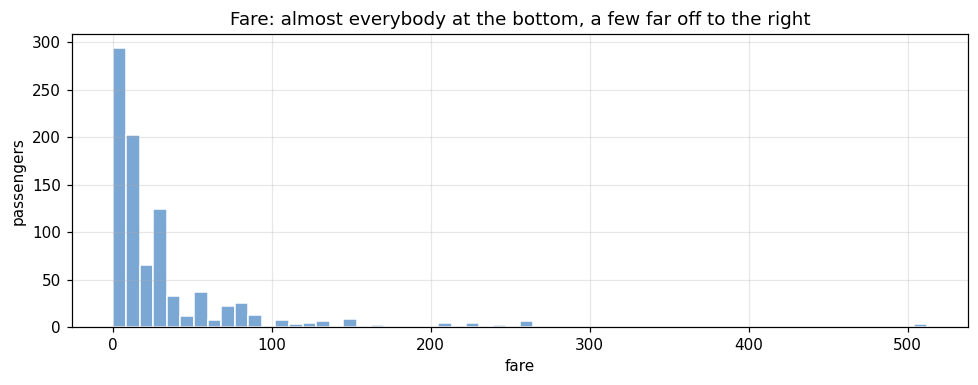

In [19]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(fare, bins=60, color='#7BA7D4', edgecolor='white')
ax.set_xlabel('fare')
ax.set_ylabel('passengers')
ax.set_title('Fare: almost everybody at the bottom, a few far off to the right')
plt.tight_layout()
plt.show()

That shape is called **right-skewed**: a big pile-up at the low end and a long thin tail stretching to the right.

Skewed data is exactly where equal-width bins fall apart. Watch what happens if we ask `pd.cut` for five bins and let it space them evenly.

In [20]:
equal_width = pd.cut(fare, bins=5)

counts = equal_width.value_counts().sort_index()
print('pd.cut(fare, bins=5) - five bins of equal WIDTH:\n')
print(counts.to_string())
print(f'\nempty bins: {(counts == 0).sum()}')
print(f'share of passengers in the first bin: {counts.iloc[0] / counts.sum():.1%}')

pd.cut(fare, bins=5) - five bins of equal WIDTH:

fare
(-0.512, 102.466]     838
(102.466, 204.932]     33
(204.932, 307.398]     17
(307.398, 409.863]      0
(409.863, 512.329]      3

empty bins: 1
share of passengers in the first bin: 94.1%


Nearly everyone lands in the first bin, and some of the upper bins hold almost nobody - possibly nobody at all.

The reason is simple once you see it. `pd.cut` divided the **range** of fares into five equal slices. The range is set by the single most expensive ticket, so four of those five slices cover territory that is essentially empty. A bin containing three passengers cannot tell you anything, and a bin containing 90% of the ship has not grouped anything.

### `pd.qcut` divides the passengers instead of the range

`pd.qcut` asks for equal-sized **groups**. You say how many you want; it works out where the boundaries have to be.

In [21]:
fare_quartile, fare_edges = pd.qcut(
    fare, q=4,
    labels=['Q1 cheapest', 'Q2', 'Q3', 'Q4 priciest'],
    retbins=True)                       # retbins=True also hands back the boundaries

print('boundaries pandas chose:\n')
for i in range(4):
    print(f'  {fare_quartile.cat.categories[i]:<12} {fare_edges[i]:>8.2f}  to {fare_edges[i+1]:>8.2f}')

print()
fare_quartile.value_counts().sort_index().to_frame('passengers')

boundaries pandas chose:

  Q1 cheapest      0.00  to     7.91
  Q2               7.91  to    14.45
  Q3              14.45  to    31.00
  Q4 priciest     31.00  to   512.33



,passengers
fare,
Q1 cheapest,223
Q2,224
Q3,222
Q4 priciest,222


Four groups of roughly equal size. Notice how **uneven the boundaries are** - the cheapest quartile spans a few pounds, the priciest spans hundreds. That is `qcut` bending the boundaries to fit the data instead of forcing the data into evenly spaced boxes.

The two approaches, side by side:

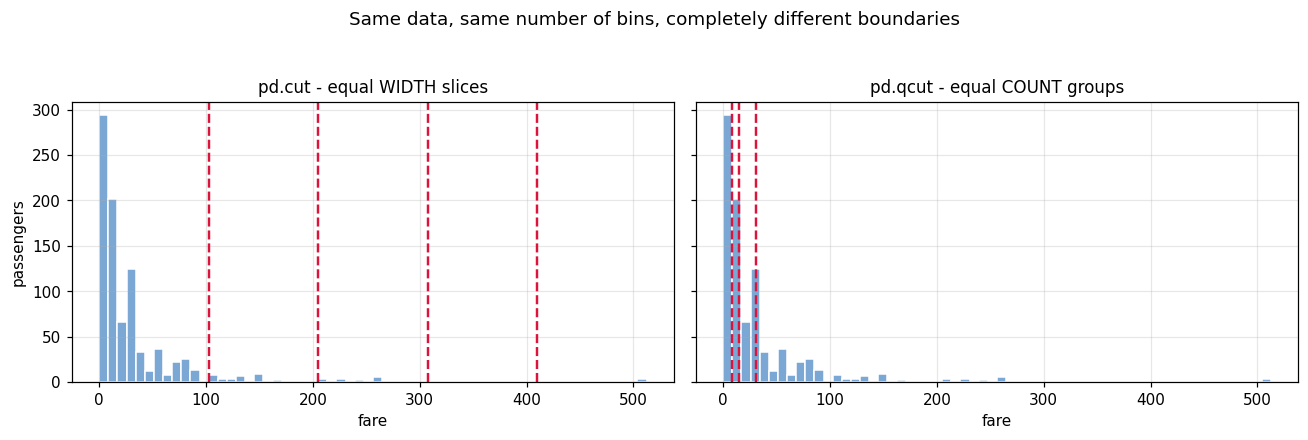

In [22]:
cut_edges = np.linspace(fare.min(), fare.max(), 6)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)

for ax, edges, title in [
    (axes[0], cut_edges,  'pd.cut - equal WIDTH slices'),
    (axes[1], fare_edges, 'pd.qcut - equal COUNT groups'),
]:
    ax.hist(fare, bins=60, color='#7BA7D4', edgecolor='white')
    for e in edges[1:-1]:
        ax.axvline(e, color='crimson', linestyle='--', linewidth=1.6)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('fare')

axes[0].set_ylabel('passengers')
fig.suptitle('Same data, same number of bins, completely different boundaries', y=1.04)
plt.tight_layout()
plt.show()

On the left, the red lines are evenly spaced and three of them sit out in empty space. On the right they cluster where the passengers actually are.

### Do the quartiles mean anything?

We invented these groups with no knowledge of 1912 ticket prices. A good way to check whether they are sensible is to compare them against something we already trust - the passenger class.

In [23]:
check = pd.crosstab(fare_quartile, titanic['pclass'], normalize='index')
check.columns = ['1st class', '2nd class', '3rd class']

print('what class were the passengers in each fare quartile?\n')
check.style.format('{:.0%}')

what class were the passengers in each fare quartile?



,1st class,2nd class,3rd class
fare,,,
Q1 cheapest,3%,3%,95%
Q2,0%,38%,62%
Q3,23%,32%,45%
Q4 priciest,72%,10%,18%


The cheapest quartile is overwhelmingly third class and the priciest is overwhelmingly first. Our boundaries, chosen with no domain knowledge whatsoever, recovered the class structure of the ship.

That is a reassuring sign - though notice it also means fare and class are largely **the same information**, so there is not much point using both.

And the question we actually care about:

In [24]:
fare_table = titanic.groupby(fare_quartile, observed=False)['survived'].agg(
    passengers='size', survival_rate='mean')

print(f'all {fare_table["passengers"].sum()} passengers accounted for '
      f'(fare has no missing values)\n')
fare_table.style.format({'survival_rate': '{:.1%}'})

all 891 passengers accounted for (fare has no missing values)



,passengers,survival_rate
fare,,
Q1 cheapest,223,19.7%
Q2,224,30.4%
Q3,222,45.5%
Q4 priciest,222,58.1%


---

## 7. `cut` or `qcut`?

| | `pd.cut` | `pd.qcut` |
|---|---|---|
| **You supply** | the boundaries | the number of groups |
| **Divides** | the range of values | the passengers |
| **Group sizes** | whatever falls out - often very uneven | roughly equal by design |
| **Boundaries** | fixed and meaningful | wherever the data puts them |
| **Good for** | age, dates, anything with real-world thresholds | money, scores, anything skewed |
| **Comparable across datasets?** | **yes** - "under 16" means the same thing everywhere | **no** - quartiles are relative to this data |

That last row is the one people forget. If you bin fares into quartiles for the Titanic and again for another ship, "Q4" means something different in each. The boundaries moved. Bins from `pd.cut` do not have that problem, because you fixed them yourself.

**A simple way to choose:** can you write down a boundary and justify it without looking at the data? If yes, use `cut`. If you find yourself thinking "well, let's see where the values fall", use `qcut`.

---

## 8. Two honest warnings

### Binning throws information away

Every bin you create destroys the differences inside it. A 30-year-old and a 49-year-old become the same passenger as far as your table is concerned.

That cost is worth paying when it buys you something - a visible step effect, a readable report, groups big enough to trust. It is not worth paying by default. If you can answer your question without binning, do that instead.

### Do not choose your boundaries by looking at the answer

This one matters. It is very tempting to try 14, then 15, then 16, then 18, and keep whichever cutoff makes the child effect look most dramatic.

If you do that, you have not discovered a threshold. You have **searched for the arrangement of the data that best supports the story you wanted**, and with enough attempts you will always find one.

In [25]:
print('The same dataset, five different "child" cutoffs:\n')
print(f'{"cutoff":>8} {"children":>10} {"child rate":>12} {"adult rate":>12} {"gap":>8}')
print('-' * 54)

for cutoff in [10, 12, 14, 16, 18, 21]:
    is_child = titanic['age'] < cutoff
    child_rate = titanic.loc[is_child, 'survived'].mean()
    adult_rate = titanic.loc[~is_child & titanic['age'].notna(), 'survived'].mean()
    print(f'{cutoff:>8} {is_child.sum():>10} {child_rate:>11.1%} {adult_rate:>12.1%} '
          f'{child_rate - adult_rate:>+8.1%}')

The same dataset, five different "child" cutoffs:

  cutoff   children   child rate   adult rate      gap
------------------------------------------------------
      10         62       61.3%        38.7%   +22.6%
      12         68       57.4%        38.9%   +18.5%
      14         71       59.2%        38.6%   +20.6%
      16         83       59.0%        38.2%   +20.8%
      18        113       54.0%        38.1%   +15.9%
      21        180       45.6%        39.0%    +6.6%


Every one of those cutoffs is defensible. They give different answers, and reporting only the most flattering one would be misleading.

**What to do instead:** pick your boundaries *before* you look at the outcome, from convention or domain knowledge, and write down why. If you do explore several, say so and show them all - as the table above does.

---

## 9. Summary

**What binning is for:** making patterns visible that are invisible in raw continuous data, and producing groups large enough to be worth reporting.

**The two tools**

```python
# You know where the lines go:
pd.cut(col, bins=[0, 16, 30, 50, 100],
       labels=['Child', 'Young adult', 'Adult', 'Senior'],
       right=False)

# You don't, and you want equal-sized groups:
pd.qcut(col, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], retbins=True)
```

**Five things to remember**

1. A near-zero correlation does not mean no relationship. It means no *straight-line* relationship - bin it and look again.
2. `right=False` includes the left edge. For ages that is almost always what you want.
3. Values outside your bins become `NaN` silently. Leave headroom at the top.
4. Missing values become `NaN` too, and then vanish from every table. Check that your groups sum to `len(df)`.
5. Fix your boundaries before you look at the outcome, and say where they came from.
